# Regular TensorFlow vs Teacher-Assisted TinyML Audio Classification

This notebook is both an experiment and a written explanation for a three-way comparison on a safety-relevant audio task: a regular TensorFlow model trained from scratch, a YAMNet transfer-learning teacher, and a distilled TinyML student model. The regular model is also quantized to int8 as a baseline reference to show the cost of quantization without distillation.

The important idea is that the **regular/YAMNet models are laptop/Colab training tools**. They do not need to fit on the ESP32. The **distilled TinyML/TFLite model is the edge-device candidate**. YAMNet is used to improve the training signal, but only the small student model is exported for ESP32-style deployment.

The comparison uses a reproducible audio dataset on the laptop or in Colab. The INMP441 microphone is soldered and the ESP32 is running, but the TinyML model is not yet deployed on the device. Once deployed, the ESP32 publishes `label`, `confidence`, `rms`, and `inference_ms` to openHAB via MQTT instead of raw audio.

Important Colab note: when this runs with a Colab kernel, files are downloaded into the **remote Colab filesystem**, not into your local Windows project folder. If you want the generated models locally, download them from Colab after the run.


## Comparison Idea

The project question is not just "can we train an audio model?". The useful question is: **how can a strong audio model help us train a small model that can actually run on the ESP32?**

This notebook uses a safety-relevant multi-dataset label strategy. Many source labels from ESC-50, UrbanSound8K, FSD50K, and the Donate-a-cry corpus are mapped into fewer deployment-oriented target labels such as `glass_breaking`, `gunshot`, `impact_or_thud`, `scream_or_shout`, `siren_or_alarm`, and `unknown_background`. This keeps the ESP32 task useful without forcing it to distinguish every tiny source-label detail.

The architecture stays clean:

```text
ML model: predict the actual sound class
ESP32/openHAB logic: map that class to a risk category and score
```

This avoids training the model directly on risk categories, which are semantically useful for the safety system but acoustically inconsistent — a gunshot, a siren, and a scream might all be high risk, but they sound completely different and cannot be learned reliably as a single acoustic class. Training on what things actually sound like and mapping to risk separately keeps both tasks solvable.

The notebook compares three things:

1. A compact CNN trained from scratch on log-mel features (also quantized to int8 as a baseline reference).
2. A YAMNet transfer-learning teacher to get stronger class probabilities from pretrained audio embeddings.
3. A distilled compact CNN student that learns from both the true labels and the YAMNet teacher, then exports to int8 TFLite for ESP32-style deployment.

YAMNet is a pretrained audio event model from TensorFlow Hub. TensorFlow's official tutorials describe using YAMNet embeddings for environmental sound transfer learning. In this notebook, YAMNet is not the deployed model. It is the teacher that helps train the small model.


In [32]:
# Run this first. A Colab kernel is remote and does not use the local .venv.
# Therefore Colab installs packages here, while the local VS Code kernel uses requirements.txt.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Colab runtime detected. Installing notebook dependencies in the remote Colab environment...')
    get_ipython().run_line_magic('pip', 'install -q tensorflow tensorflow-hub scipy soundfile numpy matplotlib scikit-learn')
else:
    print('Local kernel detected. Use the local .venv and install dependencies with:')
    print('python -m pip install -r requirements.txt')


Colab runtime detected. Installing notebook dependencies in the remote Colab environment...


In [33]:
from pathlib import Path
import os
import time
import tempfile

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow:', tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

cwd = Path.cwd()
if cwd.name == 'notebooks' and cwd.parent.name == 'tinyml':
    TINYML_ROOT = cwd.parent
elif (cwd / 'tinyml').exists():
    TINYML_ROOT = cwd / 'tinyml'
else:
    TINYML_ROOT = cwd

print('TinyML root:', TINYML_ROOT)

TensorFlow: 2.20.0
TinyML root: /content


## Dataset

This notebook uses a **multi-dataset label strategy** across four audio sources.

The safety system does not need dozens of fine-grained sound labels. It needs a smaller set of event categories that are useful for risk scoring and realistic for ESP32 deployment. Therefore, the notebook maps many source labels into fewer target labels.

Example mappings:

```text
FSD50K Thump_and_thud
FSD50K Crack
FSD50K Hammer
        -> target label: impact_or_thud

FSD50K Slam
FSD50K Domestic_sounds_and_home_sounds
        -> target label: unknown_background
```

`impact_or_thud` is kept clean of household sounds because risk scores are assigned per class in firmware — mixing a door slam with a structural thud would pollute the risk category.

Supported datasets:

- **ESC-50**: auto-downloaded, small, reproducible baseline.
- **UrbanSound8K**: auto-downloaded in Colab; useful for `gun_shot`, `siren`, `drilling`, `jackhammer`, `dog_bark`.
- **FSD50K**: large audio archive (51 197 clips across 200 AudioSet classes); needs to be uploaded to Google Drive once. Label names verified against the official FSD50K companion website 200-class list.
- **Donate-a-cry**: auto-cloned from GitHub; ~450 infant cry recordings that supplement the `crying_or_sobbing` class which FSD50K covers only thinly (~151 clips).

Target labels (12 classes):

```text
glass_breaking
gunshot
explosion_or_fireworks
impact_or_thud
scream_or_shout
siren_or_alarm
footsteps
crying_or_sobbing
pet_noise
weather_noise
mechanical_noise
unknown_background
```

`unknown_background` is an explicit escape valve. Events the model does not recognise are labelled there rather than forced into a wrong safety-relevant class.

Each class is capped at **1 200 examples** (`PER_CLASS_CAP`). This prevents high-volume FSD50K classes (Music: 14 739 clips, Domestic sounds: 6 658 clips) from dominating training. Classes limited by available audio — gunshot (~800), footsteps (~802), crying (~632 with Donate-a-cry) — are unaffected by the cap. Class weights in the regular model compensate for any remaining per-class imbalance.

Expected optional folder names under `tinyml/data/raw/` or Colab `/content/data/raw/`:

```text
UrbanSound8K/   (auto-downloaded in Colab)
FSD50K/         (manual upload to Google Drive)
donateacry-corpus/  (auto-cloned from GitHub)
```


## Colab Dataset Setup

Run this section before dataset loading when you use a Colab kernel.

- **ESC-50** is downloaded automatically (~1 min).
- **ESC-50** is downloaded automatically (~1 min).
- **ESC-50** is downloaded automatically (~1 min).
- **UrbanSound8K** is downloaded automatically (~5 min).
- **FSD50K** audio is large (~30 GB unzipped), so the notebook expects you to upload and extract it once into Google Drive and then mount Drive. The small ground-truth metadata zip is downloaded automatically.
- **Donate-a-cry** is cloned automatically from GitHub (`git clone --depth 1`) into the Colab local filesystem. No manual steps needed.

Recommended Google Drive folder for FSD50K:

```text
My Drive/tinyml_datasets/FSD50K/
```

Inside that folder, the exact subfolder names do not matter as long as the `.wav` files are somewhere below it. The notebook searches recursively.


In [34]:
# Colab dataset setup: mounts Google Drive, extracts FSD50K to Colab local, downloads UrbanSound8K.
#
# FSD50K is extracted to Colab local SSD each session (~25 min, much faster than Drive).
# UrbanSound8K is downloaded to Colab local each session (~5 min).
# Models are saved to Drive (cells 17/39) so training is never repeated.
# Safe to cancel and re-run — same-session fast path skips completed datasets.

DOWNLOAD_URBANSOUND8K = True
MOUNT_GOOGLE_DRIVE_FOR_FSD50K = True

FSD50K_DRIVE_ZIPS = "/content/drive/MyDrive/tinyml_datasets"
FSD50K_COLAB_DIR  = "/content/data/raw/FSD50K"
US8K_COLAB_DIR    = "/content/data/raw/UrbanSound8K"

from pathlib import Path
import os, tarfile, urllib.request, subprocess

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

COLAB_DATA_ROOT = Path("/content/data/raw")

def run_7z_with_progress(zip_path, out_dir):
    proc = subprocess.Popen(
        ["7z", "x", str(zip_path), f"-o{out_dir}", "-aos", "-y"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
    )
    count = 0
    for line in proc.stdout:
        line = line.rstrip()
        if line.startswith("Extracting") or line.startswith("Skipping"):
            count += 1
            if count % 500 == 0:
                print(f"    {count} files extracted...", flush=True)
    proc.wait()
    print(f"    {count} files total.")
    return proc.returncode

if IN_COLAB:
    COLAB_DATA_ROOT.mkdir(parents=True, exist_ok=True)

    # ── 1. Mount Drive (for zip files and model checkpoints) ─────────────────
    if MOUNT_GOOGLE_DRIVE_FOR_FSD50K:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
        print("Google Drive mounted.")

    # ── 2. FSD50K: extract to Colab local SSD ────────────────────────────────
    if MOUNT_GOOGLE_DRIVE_FOR_FSD50K:
        colab_fsd = Path(FSD50K_COLAB_DIR)
        if colab_fsd.exists() and len(list(colab_fsd.rglob("*.wav"))) > 100:
            n = len(list(colab_fsd.rglob("*.wav")))
            print(f"FSD50K already in Colab local storage ({n} wav files) — skipping.")
        else:
            print("Extracting FSD50K to Colab local SSD (~25 min)...")
            colab_fsd.mkdir(parents=True, exist_ok=True)
            subprocess.run(["apt-get", "install", "-q", "-y", "p7zip-full"], check=True)
            for zip_name in [
                "FSD50K.dev_audio.zip",
                "FSD50K.eval_audio.zip",
                "FSD50K.ground_truth.zip",
            ]:
                zip_path = Path(FSD50K_DRIVE_ZIPS) / zip_name
                if not zip_path.exists():
                    print(f"  Not found, skipping: {zip_name}")
                    continue
                print(f"  Extracting {zip_name}...")
                rc = run_7z_with_progress(zip_path, colab_fsd)
                if rc != 0:
                    print(f"  ERROR: 7z returned {rc} for {zip_name}")
                else:
                    print(f"  Done: {zip_name}")
            n = len(list(colab_fsd.rglob("*.wav")))
            print(f"FSD50K ready: {n} wav files.")

    # ── 3. UrbanSound8K: download to Colab local ─────────────────────────────
    if DOWNLOAD_URBANSOUND8K:
        us8k_dir = Path(US8K_COLAB_DIR)
        if (us8k_dir / "metadata" / "UrbanSound8K.csv").exists():
            print("UrbanSound8K already in Colab local storage — skipping.")
        else:
            print("Downloading UrbanSound8K (~5 min)...")
            archive = COLAB_DATA_ROOT / "UrbanSound8K.tar.gz"
            urllib.request.urlretrieve(
                "https://zenodo.org/records/1203745/files/UrbanSound8K.tar.gz?download=1", archive)
            print("Extracting...")
            with tarfile.open(archive, "r:gz") as t:
                t.extractall(COLAB_DATA_ROOT)
            archive.unlink()
            print("UrbanSound8K ready.")

else:
    print("Not in Colab. Place datasets under tinyml/data/raw/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
FSD50K already in Colab local storage (51197 wav files) — skipping.
UrbanSound8K already in Colab local storage — skipping.


In [35]:
# Download ESC-50 to Colab local storage.
# Small (~600 MB), downloads in ~1 min. Skipped if already present this session.

import zipfile, urllib.request
from pathlib import Path

DATA_ROOT = (TINYML_ROOT / 'data' / 'raw').resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)

DATA_URL = 'https://github.com/karolpiczak/ESC-50/archive/master.zip'
esc50_zip_path = DATA_ROOT / 'ESC-50-master.zip'

metadata_matches = list(DATA_ROOT.rglob('esc50.csv'))
if metadata_matches:
    print('ESC-50 already in Colab local storage — skipping.')
else:
    print('Downloading ESC-50 (~600 MB)...')
    urllib.request.urlretrieve(DATA_URL, esc50_zip_path)
    print('Extracting...')
    try:
        with zipfile.ZipFile(esc50_zip_path, 'r') as archive:
            archive.extractall(DATA_ROOT)
    except zipfile.BadZipFile:
        print('Zip was corrupt. Redownloading...')
        esc50_zip_path.unlink(missing_ok=True)
        urllib.request.urlretrieve(DATA_URL, esc50_zip_path)
        with zipfile.ZipFile(esc50_zip_path, 'r') as archive:
            archive.extractall(DATA_ROOT)
    metadata_matches = list(DATA_ROOT.rglob('esc50.csv'))

if not metadata_matches:
    raise RuntimeError('Could not find esc50.csv after download.')

esc50_metadata_path = metadata_matches[0]
esc50_dataset_dir = esc50_metadata_path.parent.parent
print('ESC-50 ready:', esc50_dataset_dir)


ESC-50 already in Colab local storage — skipping.
ESC-50 ready: /content/data/raw/ESC-50-master


In [36]:
import csv
import urllib.request
from collections import Counter, defaultdict

TARGET_LABELS = [
    'glass_breaking',
    'gunshot',
    'explosion_or_fireworks',
    'impact_or_thud',
    'scream_or_shout',
    'siren_or_alarm',
    'footsteps',
    'crying_or_sobbing',
    'pet_noise',
    'weather_noise',
    'mechanical_noise',
    'unknown_background',
]

ESC50_TO_TARGET = {
    'glass_breaking':   'glass_breaking',
    'siren':            'siren_or_alarm',
    'clock_alarm':      'siren_or_alarm',
    'fireworks':        'explosion_or_fireworks',
    'footsteps':        'footsteps',
    'crying_baby':      'crying_or_sobbing',
    'dog':              'pet_noise',
    'cat':              'pet_noise',
    'rain':             'weather_noise',
    'thunderstorm':     'weather_noise',
    'water_drops':      'weather_noise',
    'wind':             'weather_noise',
    'sea_waves':        'weather_noise',
    'crickets':         'weather_noise',
    'chainsaw':         'mechanical_noise',
    'engine':           'mechanical_noise',
    'helicopter':       'mechanical_noise',
    'hand_saw':         'mechanical_noise',
    'train':            'mechanical_noise',
    'airplane':         'mechanical_noise',
    'keyboard_typing':  'unknown_background',
    'vacuum_cleaner':   'unknown_background',
    'washing_machine':  'unknown_background',
    'clock_tick':       'unknown_background',
    'laughing':         'unknown_background',
    'clapping':         'unknown_background',
    'snoring':          'unknown_background',
    'chirping_birds':   'unknown_background',
    'crow':             'unknown_background',
    'crackling_fire':   'unknown_background',
    'car_horn':         'unknown_background',
}

URBANSOUND8K_TO_TARGET = {
    'gun_shot':          'gunshot',
    'siren':             'siren_or_alarm',
    'dog_bark':          'pet_noise',
    'drilling':          'mechanical_noise',
    'jackhammer':        'mechanical_noise',
    'air_conditioner':   'unknown_background',
    'engine_idling':     'mechanical_noise',
    'car_horn':          'unknown_background',
    'children_playing':  'unknown_background',
    'street_music':      'unknown_background',
}

# FSD50K label names verified against the official 200-class companion website.
# Compound display names "X, Y" are stored as "X_and_Y" in the ground-truth CSV
# (confirmed by v5: Crying_and_sobbing, Walk_and_footsteps, Gunshot_and_gunfire all found).
# Labels not in the 200-class list (Chainsaw, Helicopter, Baby_cry, Smoke_detector) removed.
FSD50K_TO_TARGET = {
    # Glass
    'Glass':                              'glass_breaking',
    'Shatter':                            'glass_breaking',
    'Chink_and_clink':                    'glass_breaking',   # glass tinkling / clinking
    # Gunshot
    'Gunshot_and_gunfire':                'gunshot',
    # Explosion / fireworks
    'Explosion':                          'explosion_or_fireworks',
    'Fireworks':                          'explosion_or_fireworks',
    'Boom':                               'explosion_or_fireworks',
    # Impact / thud  (kept clean: no household sounds mixed in)
    'Thump_and_thud':                     'impact_or_thud',
    'Crack':                              'impact_or_thud',
    'Hammer':                             'impact_or_thud',
    # Scream / shout
    'Screaming':                          'scream_or_shout',
    'Shout':                              'scream_or_shout',
    'Yell':                               'scream_or_shout',
    'Screech':                            'scream_or_shout',
    # Siren / alarm
    'Siren':                              'siren_or_alarm',
    'Alarm':                              'siren_or_alarm',
    'Doorbell':                           'siren_or_alarm',
    'Ringtone':                           'siren_or_alarm',
    # Footsteps
    'Walk_and_footsteps':                 'footsteps',
    'Run':                                'footsteps',
    # Crying  (Baby_cry not in FSD50K 200 classes; Crying_and_sobbing covers it)
    'Crying_and_sobbing':                 'crying_or_sobbing',
    # Pets
    'Dog':                                'pet_noise',
    'Bark':                               'pet_noise',
    'Cat':                                'pet_noise',
    'Meow':                               'pet_noise',
    'Purr':                               'pet_noise',
    'Growling':                           'pet_noise',
    'Domestic_animals_and_pets':          'pet_noise',
    # Weather
    'Rain':                               'weather_noise',
    'Raindrop':                           'weather_noise',
    'Thunder':                            'weather_noise',
    'Thunderstorm':                       'weather_noise',
    'Wind':                               'weather_noise',
    'Stream':                             'weather_noise',
    'Ocean':                              'weather_noise',
    'Waves_and_surf':                     'weather_noise',
    # Mechanical  (Chainsaw, Lawn_mower, Helicopter not in FSD50K 200-class list)
    'Drill':                              'mechanical_noise',
    'Power_tool':                         'mechanical_noise',
    'Sawing':                             'mechanical_noise',
    'Tools':                              'mechanical_noise',
    'Mechanical_fan':                     'mechanical_noise',
    'Engine':                             'mechanical_noise',
    'Motor_vehicle_(road)':               'mechanical_noise',
    'Aircraft':                           'mechanical_noise',
    'Motorcycle':                         'mechanical_noise',
    'Bus':                                'mechanical_noise',
    'Truck':                              'mechanical_noise',
    'Train':                              'mechanical_noise',
    'Rail_transport':                     'mechanical_noise',
    'Idling':                             'mechanical_noise',
    'Vehicle':                            'mechanical_noise',
    # Unknown / background
    'Speech':                             'unknown_background',
    'Music':                              'unknown_background',
    'Laughter':                           'unknown_background',
    'Chatter':                            'unknown_background',
    'Crowd':                              'unknown_background',
    'Clapping':                           'unknown_background',
    'Applause':                           'unknown_background',
    'Singing':                            'unknown_background',
    'Female_singing':                     'unknown_background',
    'Male_singing':                       'unknown_background',
    'Telephone':                          'unknown_background',
    'Knock':                              'unknown_background',
    'Slam':                               'unknown_background',
    'Domestic_sounds_and_home_sounds':    'unknown_background',
    'Computer_keyboard':                  'unknown_background',
    'Typing':                             'unknown_background',
    'Conversation':                       'unknown_background',
    'Cupboard_open_or_close':             'unknown_background',
    'Drawer_open_or_close':               'unknown_background',
    'Microwave_oven':                     'unknown_background',
    'Water':                              'unknown_background',
    'Hiss':                               'unknown_background',
    'Giggle':                             'unknown_background',
    'Cheering':                           'unknown_background',
    'Fart':                               'unknown_background',
}

TARGET_PRIORITY = {
    label: i for i, label in enumerate([
        'gunshot', 'glass_breaking', 'scream_or_shout', 'explosion_or_fireworks',
        'impact_or_thud', 'siren_or_alarm', 'crying_or_sobbing', 'footsteps',
        'mechanical_noise', 'weather_noise', 'pet_noise', 'unknown_background',
    ])
}

manifest = []

def add_example(path, source_dataset, source_label, target_label, fold):
    if target_label not in TARGET_LABELS:
        return
    manifest.append({'path': str(path), 'source_dataset': source_dataset,
                     'source_label': source_label, 'target_label': target_label, 'fold': int(fold)})

esc50_audio_dir = esc50_dataset_dir / 'audio'
with esc50_metadata_path.open(newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        source_label = row['category']
        target_label = ESC50_TO_TARGET.get(source_label)
        if target_label:
            add_example(esc50_audio_dir / row['filename'], 'ESC-50', source_label, target_label, row['fold'])

def find_urbansound8k_dir():
    candidates = [DATA_ROOT/'UrbanSound8K', DATA_ROOT/'UrbanSound8K'/'UrbanSound8K',
                  Path('/content/data/raw/UrbanSound8K'), Path('/content/UrbanSound8K')]
    for c in candidates:
        if (c/'metadata'/'UrbanSound8K.csv').exists(): return c
    matches = list(DATA_ROOT.rglob('UrbanSound8K.csv'))
    return matches[0].parent.parent if matches else None

urbansound8k_dir = find_urbansound8k_dir()
if urbansound8k_dir:
    with (urbansound8k_dir/'metadata'/'UrbanSound8K.csv').open(newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            tgt = URBANSOUND8K_TO_TARGET.get(row['class'])
            if tgt:
                audio_path = urbansound8k_dir/'audio'/f"fold{row['fold']}"/row['slice_file_name']
                fold = 1 if int(row['fold']) <= 8 else (4 if int(row['fold']) == 9 else 5)
                add_example(audio_path, 'UrbanSound8K', row['class'], tgt, fold)
    print('UrbanSound8K loaded from:', urbansound8k_dir)
else:
    print('UrbanSound8K not found.')

def download_fsd50k_ground_truth():
    zip_file = DATA_ROOT / 'FSD50K.ground_truth.zip'
    if not zip_file.exists() or zip_file.stat().st_size < 1000:
        url = 'https://zenodo.org/api/records/4060432/files/FSD50K.ground_truth.zip/content'
        print('Downloading FSD50K ground-truth metadata...')
        urllib.request.urlretrieve(url, zip_file)
    return zip_file

def find_fsd50k_audio_roots():
    candidates = [DATA_ROOT/'FSD50K', DATA_ROOT/'FSD50K.dev_audio', DATA_ROOT/'FSD50K.eval_audio',
                  Path('/content/data/raw/FSD50K'), Path('/content/FSD50K')]
    return [c for c in candidates if c.exists()]

fsd50k_audio_roots = find_fsd50k_audio_roots()
if fsd50k_audio_roots:
    fsd50k_zip = download_fsd50k_ground_truth()
    wav_index = {p.stem: p for root in fsd50k_audio_roots for p in root.rglob('*.wav')}
    print('FSD50K audio roots:', fsd50k_audio_roots)
    print('FSD50K wav files indexed:', len(wav_index))
    with zipfile.ZipFile(fsd50k_zip) as archive:
        for csv_name, default_fold in [('FSD50K.ground_truth/dev.csv', 1), ('FSD50K.ground_truth/eval.csv', 5)]:
            text = archive.read(csv_name).decode('utf-8')
            for row in csv.DictReader(text.splitlines()):
                fname = row['fname']
                audio_path = wav_index.get(str(fname))
                if audio_path is None: continue
                split_name = row.get('split', '')
                fold = 4 if split_name == 'val' else (1 if split_name == 'train' else default_fold)
                raw_labels = [lbl.strip() for lbl in row['labels'].split(',')]
                candidates = [(TARGET_PRIORITY[FSD50K_TO_TARGET[lbl]], lbl)
                              for lbl in raw_labels if lbl in FSD50K_TO_TARGET]
                if not candidates: continue
                _, best_label = min(candidates)
                add_example(audio_path, 'FSD50K', best_label, FSD50K_TO_TARGET[best_label], fold)

    # Diagnostic: confirm which v7 label additions were actually found in the audio.
    new_v7_labels = {
        'Chink_and_clink', 'Screech', 'Waves_and_surf', 'Ocean',
        'Motorcycle', 'Bus', 'Truck', 'Train', 'Rail_transport', 'Idling', 'Vehicle',
        'Domestic_animals_and_pets', 'Music', 'Clapping', 'Hiss', 'Giggle',
        'Cheering', 'Water', 'Female_singing', 'Male_singing', 'Doorbell', 'Ringtone',
        'Growling', 'Domestic_sounds_and_home_sounds',
    }
    found_labels = {ex['source_label'] for ex in manifest if ex['source_dataset'] == 'FSD50K'}
    print('\nv7 FSD50K label coverage (new or corrected entries):')
    for lbl in sorted(new_v7_labels):
        print(f'  {"FOUND" if lbl in found_labels else "not found":<10}  {lbl}')
else:
    print('FSD50K not found.')


def find_donateacry_dir():
    candidates = [
        DATA_ROOT / 'donateacry-corpus',
        DATA_ROOT / 'donateacry',
        Path('/content/data/raw/donateacry-corpus'),
        Path('/content/donateacry-corpus'),
    ]
    for c in candidates:
        if c.exists() and list(c.rglob('*.wav')):
            return c
    return None

donateacry_dir = find_donateacry_dir()
if donateacry_dir is None:
    try:
        import subprocess
        _target = DATA_ROOT / 'donateacry-corpus'
        print('Downloading Donate-a-cry corpus from GitHub...')
        subprocess.run(
            ['git', 'clone', '--depth', '1',
             'https://github.com/gveres/donateacry-corpus.git',
             str(_target)],
            check=True, capture_output=True,
        )
        donateacry_dir = _target
        print('Donate-a-cry downloaded to', donateacry_dir)
    except Exception as _e:
        print('Donate-a-cry download failed:', _e)

if donateacry_dir:
    _crying_wavs = list(donateacry_dir.rglob('*.wav'))
    print(f'Donate-a-cry: {len(_crying_wavs)} wav files')
    for _wav in _crying_wavs:
        add_example(_wav, 'DonateACry', 'crying', 'crying_or_sobbing', fold=1)
else:
    print('Donate-a-cry not found.')

PER_CLASS_CAP = 1200
rng = np.random.default_rng(42)
by_label = defaultdict(list)
for ex in manifest:
    by_label[ex['target_label']].append(ex)
manifest = []
for label, examples in by_label.items():
    if len(examples) > PER_CLASS_CAP:
        idx = rng.choice(len(examples), PER_CLASS_CAP, replace=False)
        examples = [examples[i] for i in idx]
    manifest.extend(examples)

print(f'\nCollected examples: {len(manifest)}')
print('Configured target labels:', TARGET_LABELS)
active = sorted({ex['target_label'] for ex in manifest})
print('Active model labels in this run:', active)
print('Missing target labels in this run:', [l for l in TARGET_LABELS if l not in active])
print('\nExamples by target label:')
for label in TARGET_LABELS:
    c = sum(1 for ex in manifest if ex['target_label'] == label)
    if c: print(f'  {label:<25} {c}')
print('\nExamples by source dataset:')
for ds, c in Counter(ex['source_dataset'] for ex in manifest).most_common():
    print(f'  {ds:<15} {c}')
print('\nTop source labels:')
for lbl, c in Counter(ex['source_label'] for ex in manifest).most_common(30):
    print(f'  {lbl:<40} {c}')


UrbanSound8K loaded from: /content/data/raw/UrbanSound8K
FSD50K audio roots: [PosixPath('/content/data/raw/FSD50K'), PosixPath('/content/data/raw/FSD50K')]
FSD50K wav files indexed: 51197

v7 FSD50K label coverage (new or corrected entries):
  FOUND       Bus
  FOUND       Cheering
  FOUND       Chink_and_clink
  FOUND       Clapping
  FOUND       Domestic_animals_and_pets
  FOUND       Domestic_sounds_and_home_sounds
  not found   Doorbell
  FOUND       Female_singing
  FOUND       Giggle
  FOUND       Growling
  FOUND       Hiss
  not found   Idling
  FOUND       Male_singing
  not found   Motorcycle
  FOUND       Music
  FOUND       Ocean
  FOUND       Rail_transport
  not found   Ringtone
  FOUND       Screech
  not found   Train
  not found   Truck
  FOUND       Vehicle
  FOUND       Water
  not found   Waves_and_surf
Donate-a-cry: 457 wav files

Collected examples: 12192
Configured target labels: ['glass_breaking', 'gunshot', 'explosion_or_fireworks', 'impact_or_thud', 'scream_or

## Audio Preprocessing

The ESP32 receives raw samples from the INMP441 microphone; the model is not yet deployed on the device. For this notebook, Colab or the laptop reads `.wav` files. Both paths can use the same conceptual preprocessing step: convert a short waveform window into a compact feature representation.

The first version used plain magnitude spectrograms. For ESC-50, that can be a weak baseline. This version uses **log-mel spectrograms**, which are more common for audio classification:

- STFT turns waveform samples into time/frequency energy.
- Mel filtering compresses frequencies into perceptually meaningful bands.
- Log scaling makes quiet and loud details easier for the model to compare.

This is still small enough for a TinyML-style comparison, but it is much fairer to the regular baseline than raw spectrogram magnitudes.

For ESC-50, each file is five seconds long. The notebook uses a centered two-second crop. This keeps computation manageable while giving the model more context than a very short crop.

In [37]:
# We use a fixed number of samples per example.
# ESC-50 is distributed at 44.1 kHz. A two-second center crop gives the model
# more context while keeping the notebook small enough for Colab/VS Code use.
WINDOW_SECONDS = 2.0
ESC50_SAMPLE_RATE = 44100
WINDOW_SAMPLES = int(WINDOW_SECONDS * ESC50_SAMPLE_RATE)

FRAME_LENGTH = 1024
FRAME_STEP = 512
FFT_LENGTH = 1024
NUM_MEL_BINS = 64
LOWER_HZ = 80.0
UPPER_HZ = 16000.0

import soundfile as sf
import scipy.signal
from math import gcd

mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=NUM_MEL_BINS,
    num_spectrogram_bins=FFT_LENGTH // 2 + 1,
    sample_rate=ESC50_SAMPLE_RATE,
    lower_edge_hertz=LOWER_HZ,
    upper_edge_hertz=UPPER_HZ,
)

def _decode_audio_py(path_tensor):
    """Robust WAV loader for ESC-50, UrbanSound8K, and FSD50K.

    TensorFlow's built-in decode_wav can fail on some WAV files with extended
    format chunks. soundfile/libsndfile handles those files more reliably.
    """
    path = path_tensor.numpy().decode('utf-8')
    audio, sample_rate = sf.read(path, dtype='float32', always_2d=False)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sample_rate != ESC50_SAMPLE_RATE:
        factor = gcd(int(sample_rate), int(ESC50_SAMPLE_RATE))
        up = ESC50_SAMPLE_RATE // factor
        down = int(sample_rate) // factor
        audio = scipy.signal.resample_poly(audio, up=up, down=down).astype(np.float32)

    if len(audio) > WINDOW_SAMPLES:
        start = (len(audio) - WINDOW_SAMPLES) // 2
        audio = audio[start:start + WINDOW_SAMPLES]
    elif len(audio) < WINDOW_SAMPLES:
        audio = np.pad(audio, (0, WINDOW_SAMPLES - len(audio)))

    return audio.astype(np.float32)

def decode_audio(path):
    audio = tf.py_function(_decode_audio_py, [path], tf.float32)
    audio.set_shape([WINDOW_SAMPLES])
    return audio

def waveform_to_features(waveform):
    stft = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FFT_LENGTH,
    )
    spectrogram = tf.abs(stft)
    mel_spectrogram = tf.matmul(tf.square(spectrogram), mel_weight_matrix)
    log_mel = tf.math.log(mel_spectrogram + 1e-6)
    log_mel = log_mel[..., tf.newaxis]
    return log_mel

def file_to_example(path, label):
    waveform = decode_audio(path)
    return waveform_to_features(waveform), label


In [38]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_file_dataset(ds_paths, ds_labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((ds_paths, ds_labels))
    if shuffle:
        ds = ds.shuffle(len(ds_paths), seed=42, reshuffle_each_iteration=True)
    return ds.map(file_to_example, num_parallel_calls=AUTOTUNE)

# Always use random 70/15/15 split regardless of fold assignments.
# Fold-based split gave only ~9% val; 15% gives more reliable early stopping.
paths = np.array([ex['path'] for ex in manifest])
labels = np.array([TARGET_LABELS.index(ex['target_label']) for ex in manifest])

rng = np.random.default_rng(42)
indices = rng.permutation(len(paths))
paths_s  = paths[indices]
labels_s = labels[indices]

n_train = int(0.70 * len(paths_s))
n_val   = int(0.15 * len(paths_s))

train_paths, train_labels = paths_s[:n_train],              labels_s[:n_train]
val_paths,   val_labels   = paths_s[n_train:n_train+n_val], labels_s[n_train:n_train+n_val]
test_paths,  test_labels  = paths_s[n_train+n_val:],        labels_s[n_train+n_val:]


def spec_augment(spec, label):
    S = tf.squeeze(spec, axis=-1)  # (T, F)
    T_len = tf.shape(S)[0]
    F_len = tf.shape(S)[1]
    # Two frequency masks: mask up to 15 consecutive mel bins.
    for _ in range(2):
        f  = tf.random.uniform([], 0, 15, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, F_len - f, dtype=tf.int32)
        idx  = tf.range(F_len)
        mask = tf.cast(tf.logical_or(idx < f0, idx >= f0 + f), tf.float32)
        S = S * mask[tf.newaxis, :]
    # Two time masks: mask up to 30 consecutive frames.
    for _ in range(2):
        t  = tf.random.uniform([], 0, 30, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, T_len - t, dtype=tf.int32)
        idx  = tf.range(T_len)
        mask = tf.cast(tf.logical_or(idx < t0, idx >= t0 + t), tf.float32)
        S = S * mask[:, tf.newaxis]
    return tf.expand_dims(S, axis=-1), label


LABELS = TARGET_LABELS # Define LABELS using TARGET_LABELS
def print_distribution(name, values):
    counts = np.bincount(values.astype(int), minlength=len(LABELS))
    print(name)
    for label_name, count in zip(LABELS, counts):
        print(f'  {label_name:28s} {int(count)}')
    return counts

train_counts = print_distribution('Train distribution:', train_labels)
val_counts   = print_distribution('Validation distribution:', val_labels)
test_counts  = print_distribution('Test distribution:', test_labels)

total_train = float(np.sum(train_counts))
class_weight = {
    i: total_train / (len(LABELS) * count)
    for i, count in enumerate(train_counts)
    if count > 0
}
print('Class weights:', class_weight)

_raw_train_ds = make_file_dataset(train_paths, train_labels, shuffle=True)
val_ds  = make_file_dataset(val_paths,  val_labels).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_ds = make_file_dataset(test_paths, test_labels).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

# Apply SpecAugment only to train. Do NOT cache before augment.
train_ds = (
    _raw_train_ds
    .map(spec_augment, num_parallel_calls=AUTOTUNE)
    .shuffle(4000, seed=42, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('Train/val/test files:', len(train_paths), len(val_paths), len(test_paths))
for example_specs, example_labels in train_ds.take(1):
    INPUT_SHAPE = example_specs.shape[1:]
    print('Input shape:', INPUT_SHAPE)
    print('Example labels:', [LABELS[int(i)] for i in example_labels[:8].numpy()])


Train distribution:
  glass_breaking               852
  gunshot                      606
  explosion_or_fireworks       639
  impact_or_thud               591
  scream_or_shout              602
  siren_or_alarm               841
  footsteps                    597
  crying_or_sobbing            428
  pet_noise                    845
  weather_noise                830
  mechanical_noise             873
  unknown_background           830
Validation distribution:
  glass_breaking               171
  gunshot                      126
  explosion_or_fireworks       150
  impact_or_thud               128
  scream_or_shout              127
  siren_or_alarm               192
  footsteps                    126
  crying_or_sobbing            103
  pet_noise                    171
  weather_noise                181
  mechanical_noise             173
  unknown_background           180
Test distribution:
  glass_breaking               177
  gunshot                      124
  explosion_or_fireworks  

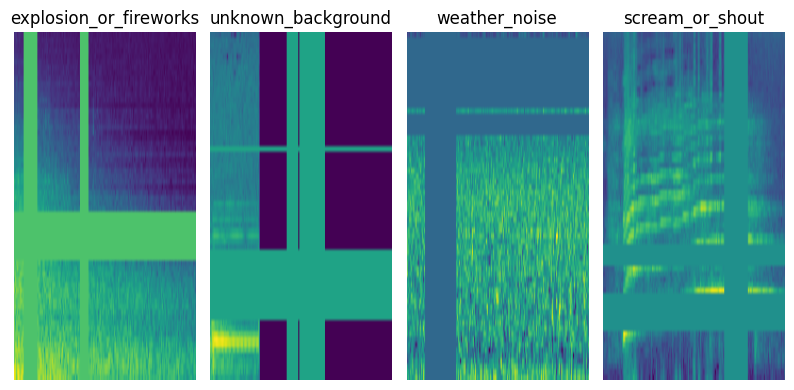

In [39]:
plt.figure(figsize=(8, 4))
for specs, batch_labels in train_ds.take(1):
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(tf.squeeze(specs[i]).numpy().T, aspect='auto', origin='lower')
        plt.title(LABELS[int(batch_labels[i])])
        plt.axis('off')
plt.tight_layout()

## Confusion Matrix Helper

The selected subset has more labels than the first prototype. The helper below scales the figure size automatically, rotates the labels, and saves a PNG copy into `tinyml/exported/figures`. This keeps confusion matrices readable even if we later expand the subset again.


In [40]:
FIGURES_DIR = (TINYML_ROOT / 'exported' / 'figures').resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def plot_confusion(y_true, y_pred, title, filename, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
    fig_size = max(8, 0.65 * len(LABELS))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(cmap=cmap, xticks_rotation=60, ax=ax, colorbar=False)
    ax.set_title(title)
    ax.tick_params(axis='both', labelsize=8)
    plt.tight_layout()
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    print('Saved confusion matrix:', output_path)
    return cm


## Regular TensorFlow Model

This is the laptop/Colab baseline. It is intentionally treated as the normal machine-learning version of the task.

The baseline should be reasonably strong before the TinyML comparison is interpreted. If the regular model collapses into predicting one class, the TinyML comparison is not useful yet.

This version uses log-mel inputs and a compact CNN without BatchNormalization layers. BatchNormalization can work well, but with small audio datasets it can sometimes make evaluation behavior unstable. A normalized input plus plain convolution blocks is a simpler and more stable baseline for this comparison.

In [41]:
normalization_layer = tf.keras.layers.Normalization()
normalization_layer.adapt(train_ds.map(lambda x, y: x))

regular_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=INPUT_SHAPE),
    normalization_layer,

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(96, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(96, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(len(LABELS), activation='softmax'),
])

regular_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

regular_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 171, 64, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 171, 64, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 85, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 85, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 42, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 42, 16, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 21, 8, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 8, 128)     │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,479 (775.31 KB)

 Trainable params: 198,476 (775.30 KB)

 Non-trainable params: 3 (16.00 B)

In [42]:
DRIVE_ROOT = None
try:
    import google.colab  # type: ignore
    _dm = __import__("pathlib").Path("/content/drive/MyDrive/tinyml_models")
    if _dm.parent.exists():
        _dm.mkdir(parents=True, exist_ok=True)
        DRIVE_ROOT = _dm
except ImportError:
    pass

_regular_ckpt = DRIVE_ROOT / f"regular_model_best_{FEATURE_CACHE_VERSION}.keras" if DRIVE_ROOT else None

_load_regular = False
if _regular_ckpt and _regular_ckpt.exists():
    _probe = tf.keras.models.load_model(str(_regular_ckpt))
    _saved_classes = _probe.output_shape[-1]
    if _saved_classes != len(LABELS):
        print(f"Stale Drive checkpoint: {_saved_classes} classes but current run has {len(LABELS)}.")
        print("Deleting checkpoint and retraining with correct label set.")
        _regular_ckpt.unlink()
    else:
        regular_model = _probe
        history = None
        _load_regular = True
        print("Loaded regular model from Drive:", _regular_ckpt)

if not _load_regular:
    print("Training regular model from scratch.")
    if _regular_ckpt:
        print("Will save best checkpoint to:", _regular_ckpt)
    checkpoint_callbacks = []
    if _regular_ckpt:
        checkpoint_callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(_regular_ckpt),
                monitor="val_accuracy", save_best_only=True, mode="max", verbose=1,
            )
        ]
    history = regular_model.fit(
        train_ds, validation_data=val_ds, epochs=40,
        class_weight=class_weight,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy", mode="max", patience=8,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_accuracy", mode="max", patience=3,
                factor=0.5, min_lr=1e-5,
            ),
        ] + checkpoint_callbacks,
    )


Loaded regular model from Drive: /content/drive/MyDrive/tinyml_models/regular_model_best_v8.keras


In [43]:
# Save trained models and exports to Google Drive so they survive session drops.
# Re-run this cell any time after training to refresh the Drive copy.
import shutil
from pathlib import Path

try:
    import google.colab  # type: ignore
    _in_colab = True
except ImportError:
    _in_colab = False

if _in_colab:
    drive_root = Path("/content/drive/MyDrive/tinyml_models")
    if not Path("/content/drive").exists():
        print("Drive not mounted. Run cell 6 first, then re-run this cell.")
    else:
        drive_root.mkdir(parents=True, exist_ok=True)
        # Use MODELS_DIR/EXPORTED_DIR if already defined (cell 26), else fall back to defaults.
        try:
            _models_dir = MODELS_DIR
            _exported_dir = EXPORTED_DIR
        except NameError:
            _tinyml_root = Path("/content/tinyml") if Path("/content/tinyml").exists() else Path.cwd()
            _models_dir = (_tinyml_root / "models").resolve()
            _exported_dir = (_tinyml_root / "exported").resolve()

        for src_dir, label in [(_models_dir, "models"), (_exported_dir, "exported")]:
            dst_dir = drive_root / label
            if src_dir.exists():
                shutil.copytree(str(src_dir), str(dst_dir), dirs_exist_ok=True)
                print(f"Saved {label}/ -> {dst_dir}")
            else:
                print(f"Skipped {label}/ (not found: {src_dir})")
        print("Drive backup complete:", drive_root)
else:
    print("Not in Colab — skipping Drive save.")


Saved models/ -> /content/drive/MyDrive/tinyml_models/models
Saved exported/ -> /content/drive/MyDrive/tinyml_models/exported
Drive backup complete: /content/drive/MyDrive/tinyml_models


## Training Curves

The curves help distinguish two different problems:

- If training accuracy is low, the model/features are too weak.
- If training accuracy is high but validation accuracy is low, the model is overfitting.

This is useful for deciding whether to improve preprocessing, model size, or regularization.

In [44]:
if history is not None:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='validation')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='validation')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
else:
    print("Training was skipped, so no history to plot.")

Training was skipped, so no history to plot.


In [45]:
expected_output_units = len(LABELS)
actual_output_units = regular_model.layers[-1].units

if actual_output_units != expected_output_units:
    print(f"Error: Mismatch in number of output classes.")
    print(f"Loaded regular_model expects {actual_output_units} classes (range 0-{actual_output_units-1}),")
    print(f"but current LABELS variable defines {expected_output_units} classes (range 0-{expected_output_units-1}).")
    print(f"This often happens when loading a pre-trained model after changing the dataset's label set.")
    print(f"Please re-run the training step (cell a7d22d41) or ensure the loaded model matches the current label configuration.")
    # To prevent further errors in this cell, we can assign NaN to results.
    regular_loss = float('nan')
    regular_accuracy = float('nan')
else:
    regular_loss, regular_accuracy = regular_model.evaluate(test_ds)

print('Regular test accuracy:', regular_accuracy)

58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 381ms/step - accuracy: 0.6470 - loss: 1.1668
Regular test accuracy: 0.6469945311546326


## Regular Model Diagnostics

Accuracy alone is not enough. A confusion matrix shows which categories the model confuses. This matters especially for the combined safety dataset because several labels are intentionally broad, such as `impact_or_thud`, `weather_noise`, and `mechanical_noise`.

This cell also prints the predicted label distribution. If almost everything is predicted as one class, the model has collapsed. In that case, the next step is not to interpret TinyML yet, but to improve the regular baseline.

Chance accuracy depends on how many target labels are active in the current run. The notebook prints the active labels after dataset loading. A useful baseline should be clearly above chance and should predict more than one class.


Regular true label distribution:
  glass_breaking               177
  gunshot                      124
  explosion_or_fireworks       140
  impact_or_thud               131
  scream_or_shout              130
  siren_or_alarm               167
  footsteps                    143
  crying_or_sobbing            101
  pet_noise                    184
  weather_noise                189
  mechanical_noise             154
  unknown_background           190
Regular predicted label distribution:
  glass_breaking               200
  gunshot                      133
  explosion_or_fireworks       114
  impact_or_thud               155
  scream_or_shout              134
  siren_or_alarm               156
  footsteps                    172
  crying_or_sobbing            94
  pet_noise                    187
  weather_noise                191
  mechanical_noise             176
  unknown_background           118
Saved confusion matrix: /content/exported/figures/regular_tensorflow_confusion_matrix.png


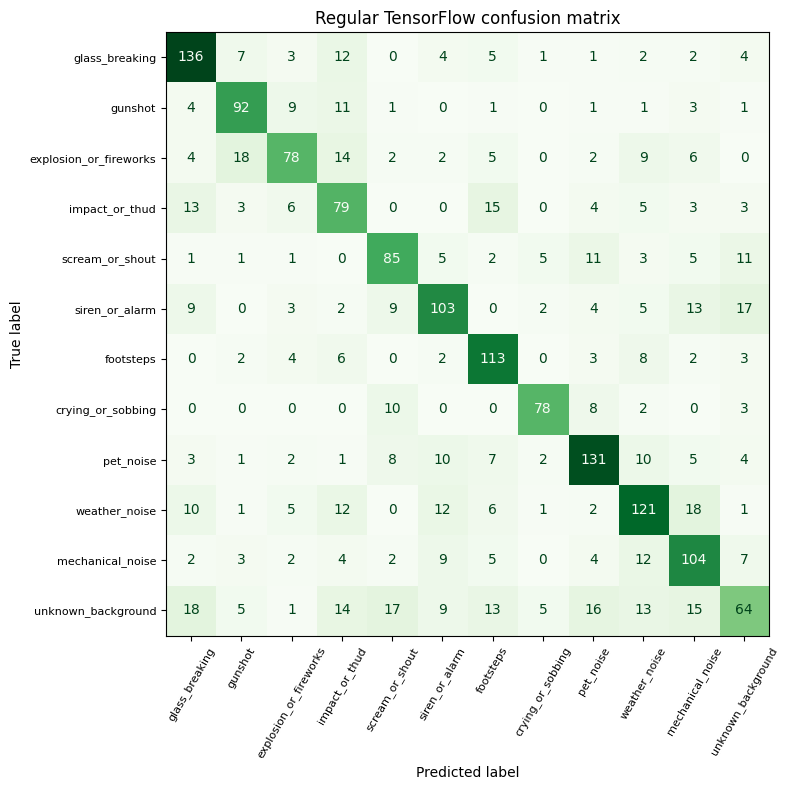

In [46]:
regular_y_true = []
regular_y_pred = []

for specs, labels_batch in test_ds:
    probs = regular_model.predict(specs, verbose=0)
    preds = np.argmax(probs, axis=1)
    regular_y_true.extend(labels_batch.numpy().astype(int).tolist())
    regular_y_pred.extend(preds.astype(int).tolist())

print_distribution('Regular true label distribution:', np.array(regular_y_true))
print_distribution('Regular predicted label distribution:', np.array(regular_y_pred))

regular_cm = plot_confusion(
    regular_y_true,
    regular_y_pred,
    'Regular TensorFlow confusion matrix',
    'regular_tensorflow_confusion_matrix.png',
    cmap='Greens',
)


### If The Regular Accuracy Is Low

Low accuracy is a useful result, but it changes the conclusion. It means the current baseline setup is too weak for the task, not that TinyML is impossible. Likely reasons with the multi-dataset setup:

- Some target labels are acoustically broad. `mechanical_noise` covers motorcycles, drills, aircraft, and trains — the model has to generalise across very different sounds in one class.
- Some classes have fewer than the 1 200-clip cap (gunshot ~850, footsteps ~850, crying ~632). The cap limits high-volume classes but cannot add clips that do not exist.
- The two-second center crop may miss the relevant sound event in longer clips from FSD50K or UrbanSound8K.
- The regular model is intentionally compact (no BatchNorm, no pretrained weights) to make the comparison meaningful. A weaker baseline makes the teacher and distilled student gains more visible, not less.

If the model collapses to predicting one class, check the confusion matrix distribution first. Class collapse usually means a training bug (wrong class weights or a badly imbalanced split), not a model-capacity issue. For the comparison, the key is that the regular model and the distilled student use the **same** preprocessing and label set.

## Convert To TensorFlow Lite And Quantize

This section creates the TinyML-style comparison model. The model is converted to TensorFlow Lite and then quantized to int8.

Quantization matters because microcontrollers have much less memory and compute power than a laptop. Int8 values are smaller than float32 values, so the model file is usually much smaller. The tradeoff is that accuracy can get slightly worse. That tradeoff is one of the main things this notebook measures.

Strictly speaking, an ESP32 firmware would usually use **TFLite Micro**, not the normal Python TFLite interpreter. But the `.tflite` int8 model produced here is the relevant artifact direction for that later firmware step.

In [47]:
MODELS_DIR = (TINYML_ROOT / 'models').resolve()
EXPORTED_DIR = (TINYML_ROOT / 'exported').resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)
EXPORTED_DIR.mkdir(parents=True, exist_ok=True)

regular_keras_path = MODELS_DIR / 'regular_model.keras'
regular_tflite_path = MODELS_DIR / 'regular_model_float32.tflite'
tiny_tflite_path = MODELS_DIR / 'tiny_model_int8.tflite'

regular_model.save(regular_keras_path)

converter = tf.lite.TFLiteConverter.from_keras_model(regular_model)
regular_tflite = converter.convert()
regular_tflite_path.write_bytes(regular_tflite)

def representative_dataset():
    for specs, _ in train_ds.unbatch().batch(1).take(100):
        yield [tf.cast(specs, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(regular_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tiny_tflite = converter.convert()
tiny_tflite_path.write_bytes(tiny_tflite)

print('Saved:', regular_keras_path)
print('Saved:', regular_tflite_path)
print('Saved:', tiny_tflite_path)

Saved artifact at '/tmp/tmplpjoi_o6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 171, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  136782546935376: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  136782546932880: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  136782500639952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500632464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500630928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500640528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500633616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500634192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500632272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782500630544: TensorSpec(shape=(), dtype=tf.resource, name=None)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: /content/models/regular_model.keras
Saved: /content/models/regular_model_float32.tflite
Saved: /content/models/tiny_model_int8.tflite


In [48]:
def evaluate_tflite_model(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    correct = 0
    total = 0
    y_true = []
    y_pred = []
    timings_ms = []

    for specs, labels_batch in dataset.unbatch().batch(1):
        input_data = specs.numpy().astype(np.float32)
        if input_details['dtype'] == np.int8:
            input_data = input_data / input_scale + input_zero_point
            input_data = np.clip(input_data, -128, 127).astype(np.int8)

        start = time.perf_counter()
        interpreter.set_tensor(input_details['index'], input_data)
        interpreter.invoke()
        elapsed_ms = (time.perf_counter() - start) * 1000

        output = interpreter.get_tensor(output_details['index'])[0]
        if output_details['dtype'] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output))
        true = int(labels_batch.numpy()[0])
        correct += int(pred == true)
        total += 1
        y_true.append(true)
        y_pred.append(pred)
        timings_ms.append(elapsed_ms)

    return {
        'accuracy': correct / total,
        'avg_inference_ms_laptop': float(np.mean(timings_ms)),
        'y_true': y_true,
        'y_pred': y_pred,
    }

regular_tflite_eval = evaluate_tflite_model(regular_tflite_path, test_ds)
tiny_tflite_eval = evaluate_tflite_model(tiny_tflite_path, test_ds)

regular_tflite_eval['accuracy'], tiny_tflite_eval['accuracy']

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


(0.6469945355191257, 0.644808743169399)

In [49]:
size_regular_keras = regular_keras_path.stat().st_size
size_regular_tflite = regular_tflite_path.stat().st_size
size_tiny_tflite = tiny_tflite_path.stat().st_size

comparison = {
    'metric': ['target', 'numeric_format', 'model_size_bytes', 'accuracy', 'avg_inference_ms_laptop', 'openhab_payload'],
    'regular_tensorflow': [
        'Laptop baseline',
        'float32',
        size_regular_keras,
        float(regular_accuracy),
        'not measured here',
        'could send raw/central features, but not privacy-friendly',
    ],
    'tinyml_tflite_int8': [
        'ESP32 candidate style',
        'int8',
        size_tiny_tflite,
        tiny_tflite_eval['accuracy'],
        tiny_tflite_eval['avg_inference_ms_laptop'],
        'label/confidence/rms/inference_ms only',
    ],
}

for row in zip(comparison['metric'], comparison['regular_tensorflow'], comparison['tinyml_tflite_int8']):
    print(f'{row[0]:28s} | {str(row[1]):35s} | {row[2]}')

target                       | Laptop baseline                     | ESP32 candidate style
numeric_format               | float32                             | int8
model_size_bytes             | 2439892                             | 215552
accuracy                     | 0.6469945311546326                  | 0.644808743169399
avg_inference_ms_laptop      | not measured here                   | 3.7339534578682527
openhab_payload              | could send raw/central features, but not privacy-friendly | label/confidence/rms/inference_ms only


## TinyML Confusion Matrix

This is the same diagnostic view for the quantized TFLite model. Compare it with the regular confusion matrix above. The important question is not only whether TinyML is accurate, but **how much accuracy changes after conversion and quantization**.

Saved confusion matrix: /content/exported/figures/plain_tinyml_int8_confusion_matrix.png


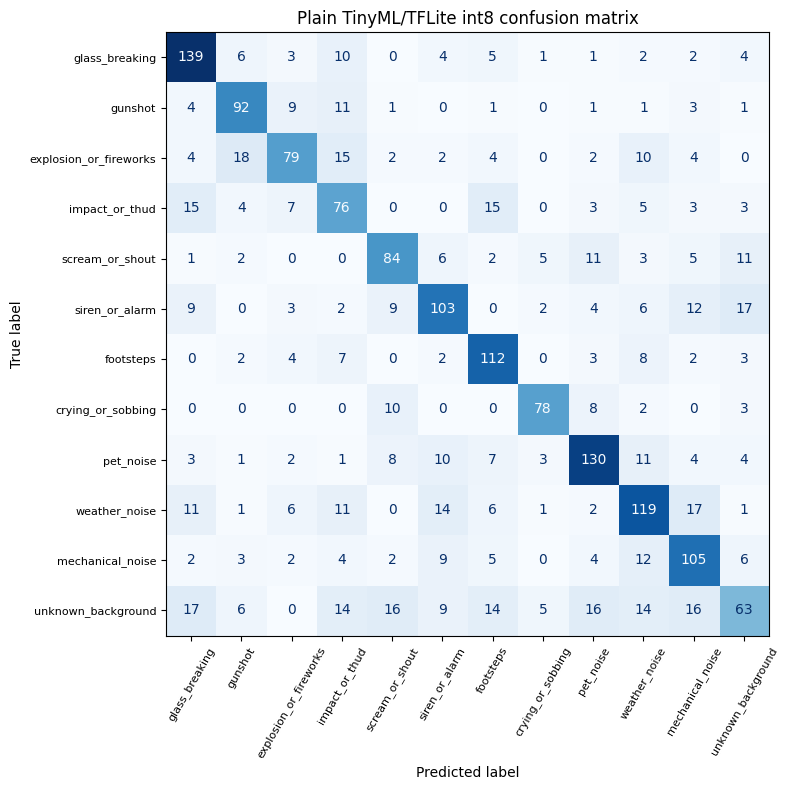

In [50]:
cm = plot_confusion(
    tiny_tflite_eval['y_true'],
    tiny_tflite_eval['y_pred'],
    'Plain TinyML/TFLite int8 confusion matrix',
    'plain_tinyml_int8_confusion_matrix.png',
    cmap='Blues',
)


## Transfer Learning Baseline

Training from scratch on a compact CNN gives a useful baseline, but pretrained audio knowledge can improve it significantly. Transfer learning tests a different question: what if we use a pretrained audio model as the feature extractor?

This section uses YAMNet from TensorFlow Hub. YAMNet was trained on AudioSet and returns 1 024-dimensional embeddings for audio windows. We freeze YAMNet, extract embeddings, and train a small Dense classifier head on top. This typically gives higher accuracy than the scratch CNN because it starts from audio representations that already encode spectral patterns across hundreds of sound categories.

YAMNet is not the deployed model. It is the teacher/reference that helps train the small student.


In [51]:
import scipy.signal
import tensorflow_hub as hub

yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print('Loaded YAMNet from TensorFlow Hub')

Loaded YAMNet from TensorFlow Hub


In [52]:
YAMNET_SAMPLE_RATE = 16000
# Bump this string if you change the dataset split to invalidate the cache.
FEATURE_CACHE_VERSION = "v10"  # feature cache and teacher/regular checkpoints (v10: two-phase YAMNet fine-tuning)
STUDENT_VERSION = "v10"       # student checkpoint only — bump this when student training changes

def load_audio_for_yamnet(path):
    audio, sample_rate = sf.read(str(path), dtype="float32", always_2d=False)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    if sample_rate != YAMNET_SAMPLE_RATE:
        factor = gcd(int(sample_rate), int(YAMNET_SAMPLE_RATE))
        up = YAMNET_SAMPLE_RATE // factor
        down = int(sample_rate) // factor
        audio = scipy.signal.resample_poly(audio, up=up, down=down).astype(np.float32)
    return audio.astype(np.float32)

def extract_yamnet_embedding(path):
    waveform = load_audio_for_yamnet(path)
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return tf.reduce_mean(embeddings, axis=0).numpy()

def build_yamnet_feature_matrix(ds_paths, ds_labels, name):
    features = []
    for i, path in enumerate(ds_paths):
        if i % 20 == 0:
            print(f"{name}: {i}/{len(ds_paths)}", flush=True)
        features.append(extract_yamnet_embedding(path))
    return np.stack(features).astype(np.float32), ds_labels.astype(np.int64)

def _yamnet_cache_dir():
    if DRIVE_ROOT:
        d = DRIVE_ROOT / "cache" / FEATURE_CACHE_VERSION / "yamnet"
        d.mkdir(parents=True, exist_ok=True)
        return d
    return None

def load_or_build_yamnet(ds_paths, ds_labels, split_name):
    cache_dir = _yamnet_cache_dir()
    fx = cache_dir / f"{split_name}_x.npy" if cache_dir else None
    fy = cache_dir / f"{split_name}_y.npy" if cache_dir else None
    if fx and fx.exists() and fy and fy.exists():
        print(f"Loading YAMNet {split_name} embeddings from Drive cache...")
        return np.load(str(fx)), np.load(str(fy))
    print(f"Computing YAMNet {split_name} embeddings (will cache to Drive)...")
    x, y = build_yamnet_feature_matrix(ds_paths, ds_labels, split_name)
    if fx:
        np.save(str(fx), x)
        np.save(str(fy), y)
        print(f"Cached {split_name} embeddings to Drive: {fx}")
    return x, y

yamnet_train_x, yamnet_train_y = load_or_build_yamnet(train_paths, train_labels, "train")
yamnet_val_x,   yamnet_val_y   = load_or_build_yamnet(val_paths,   val_labels,   "val")
yamnet_test_x,  yamnet_test_y  = load_or_build_yamnet(test_paths,  test_labels,  "test")
print(yamnet_train_x.shape, yamnet_val_x.shape, yamnet_test_x.shape)


Loading YAMNet train embeddings from Drive cache...
Loading YAMNet val embeddings from Drive cache...
Loading YAMNet test embeddings from Drive cache...
(8534, 1024) (1828, 1024) (1830, 1024)


In [53]:
_teacher_ckpt = DRIVE_ROOT / f'yamnet_teacher_best_{FEATURE_CACHE_VERSION}.keras' if DRIVE_ROOT else None

_load_teacher = False
if _teacher_ckpt and _teacher_ckpt.exists():
    _probe = tf.keras.models.load_model(str(_teacher_ckpt))
    if _probe.output_shape[-1] != len(LABELS):
        print(f'Stale teacher checkpoint ({_probe.output_shape[-1]} classes). Deleting.')
        _teacher_ckpt.unlink()
    else:
        transfer_model = _probe
        transfer_history = None
        _load_teacher = True
        print('Loaded YAMNet teacher from Drive:', _teacher_ckpt)

if not _load_teacher:
    # ── Phase 1: Dense head on frozen YAMNet embeddings ──────────────────────
    print('Phase 1: Training Dense head on frozen YAMNet embeddings...')
    transfer_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(yamnet_train_x.shape[1],)),
        tf.keras.layers.Dense(512, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Dense(256, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(len(LABELS), activation='softmax'),
    ])
    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    transfer_history = transfer_model.fit(
        yamnet_train_x, yamnet_train_y,
        validation_data=(yamnet_val_x, yamnet_val_y),
        epochs=80,
        class_weight=class_weight,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', mode='max', patience=12,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_accuracy', mode='max', patience=5,
                factor=0.5, min_lr=1e-5,
            ),
        ],
    )
    print('Phase 1 complete.')

    # ── Phase 2: Fine-tune YAMNet + Dense head end-to-end ────────────────────
    # hub.KerasLayer(trainable=True) exposes YAMNet variables to GradientTape.
    # LR=1e-5 (100× lower than Phase 1) prevents catastrophic forgetting.
    print('\nPhase 2: Fine-tuning YAMNet + Dense head end-to-end (LR=1e-5)...')

    _FT_WINDOW   = 32000   # 2 s at 16 kHz → fixed number of YAMNet frames per clip
    _FT_EPOCHS   = 10
    _FT_BATCH    = 4
    _FT_PATIENCE = 3

    def _load_fixed_wave(path):
        w = load_audio_for_yamnet(path)
        if len(w) >= _FT_WINDOW:
            s = max(0, (len(w) - _FT_WINDOW) // 2)
            return w[s : s + _FT_WINDOW]
        return np.pad(w, (0, _FT_WINDOW - len(w)))

    _yamnet_ft = hub.KerasLayer('https://tfhub.dev/google/yamnet/1', trainable=True)
    _ = _yamnet_ft(tf.zeros(_FT_WINDOW, dtype=tf.float32))   # build layer weights
    print(f'  YAMNet fine-tune layer ready: {len(_yamnet_ft.trainable_variables)} variable tensors')

    _ft_opt     = tf.keras.optimizers.Adam(learning_rate=1e-5)
    _ft_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    _all_ft_vars = _yamnet_ft.trainable_variables + transfer_model.trainable_variables

    _best_val_acc = 0.0
    _no_improve   = 0

    for _ep in range(_FT_EPOCHS):
        _perm      = np.random.permutation(len(train_paths))
        _ep_losses = []

        for _b in range(0, len(_perm), _FT_BATCH):
            _idx   = list(_perm[_b : _b + _FT_BATCH])
            _waves = [tf.constant(_load_fixed_wave(train_paths[i])) for i in _idx]
            _lbls  = tf.constant(train_labels[_idx])

            with tf.GradientTape() as _tape:
                # Process each waveform individually; stack embeddings into a batch.
                _embs = tf.stack([
                    tf.reduce_mean(_yamnet_ft(w)[1], axis=0) for w in _waves
                ])  # (batch, 1024)
                _loss = _ft_loss_fn(_lbls, transfer_model(_embs, training=True))

            _grads = _tape.gradient(_loss, _all_ft_vars)
            _ft_opt.apply_gradients(zip(_grads, _all_ft_vars))
            _ep_losses.append(float(_loss))

        # Validation
        _vp, _vt = [], []
        for _b in range(0, len(val_paths), _FT_BATCH):
            _end   = min(_b + _FT_BATCH, len(val_paths))
            _waves = [tf.constant(_load_fixed_wave(val_paths[i])) for i in range(_b, _end)]
            _embs  = tf.stack([tf.reduce_mean(_yamnet_ft(w)[1], axis=0) for w in _waves])
            _vp.append(np.argmax(transfer_model(_embs).numpy(), axis=1))
            _vt.append(val_labels[_b : _end])
        _val_acc = float(np.mean(np.concatenate(_vp) == np.concatenate(_vt)))
        print(f'  FT {_ep+1}/{_FT_EPOCHS}  loss={np.mean(_ep_losses):.4f}  val_acc={_val_acc:.4f}')

        if _val_acc > _best_val_acc:
            _best_val_acc = _val_acc
            _no_improve   = 0
        else:
            _no_improve += 1
            if _no_improve >= _FT_PATIENCE:
                print(f'  Early stop at epoch {_ep+1} (patience={_FT_PATIENCE}).')
                break

    print(f'Phase 2 complete. Best val_acc: {_best_val_acc:.4f}')

    # ── Phase 3: Re-extract all embeddings with fine-tuned YAMNet ────────────
    # The student trains on teacher soft labels derived from these embeddings,
    # so better embeddings → better soft labels → better student.
    print('\nPhase 3: Re-extracting embeddings with fine-tuned YAMNet...')

    def _extract_ft_emb(path):
        w = tf.constant(load_audio_for_yamnet(path))
        _, embs, _ = _yamnet_ft(w)
        return tf.reduce_mean(embs, axis=0).numpy()

    def _rebuild_and_cache(paths, labels, split_name):
        feats = []
        for i, p in enumerate(paths):
            if i % 100 == 0:
                print(f'  {split_name}: {i}/{len(paths)}', flush=True)
            feats.append(_extract_ft_emb(p))
        x = np.stack(feats).astype(np.float32)
        y = np.array(labels, dtype=np.int64)
        cache_dir = _yamnet_cache_dir()
        if cache_dir:
            np.save(str(cache_dir / f'{split_name}_x.npy'), x)
            np.save(str(cache_dir / f'{split_name}_y.npy'), y)
            print(f'  Saved {split_name} → {cache_dir}')
        return x, y

    yamnet_train_x, yamnet_train_y = _rebuild_and_cache(train_paths, train_labels, 'train')
    yamnet_val_x,   yamnet_val_y   = _rebuild_and_cache(val_paths,   val_labels,   'val')
    yamnet_test_x,  yamnet_test_y  = _rebuild_and_cache(test_paths,  test_labels,  'test')
    print('Phase 3 complete. Fine-tuned embeddings cached to Drive.')

    if _teacher_ckpt:
        transfer_model.save(str(_teacher_ckpt))
        print('Saved teacher checkpoint to Drive:', _teacher_ckpt)

transfer_loss, transfer_accuracy = transfer_model.evaluate(yamnet_test_x, yamnet_test_y)
print('YAMNet transfer test accuracy:', transfer_accuracy)


Loaded YAMNet teacher from Drive: /content/drive/MyDrive/tinyml_models/yamnet_teacher_best_v8.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7568 - loss: 1.3576
YAMNet transfer test accuracy: 0.7568305730819702


YAMNet transfer true label distribution:
  glass_breaking               177
  gunshot                      124
  explosion_or_fireworks       140
  impact_or_thud               131
  scream_or_shout              130
  siren_or_alarm               167
  footsteps                    143
  crying_or_sobbing            101
  pet_noise                    184
  weather_noise                189
  mechanical_noise             154
  unknown_background           190
YAMNet transfer predicted label distribution:
  glass_breaking               178
  gunshot                      119
  explosion_or_fireworks       148
  impact_or_thud               144
  scream_or_shout              140
  siren_or_alarm               154
  footsteps                    150
  crying_or_sobbing            99
  pet_noise                    172
  weather_noise                193
  mechanical_noise             171
  unknown_background           162
Saved confusion matrix: /content/exported/figures/yamnet_teacher_confusion

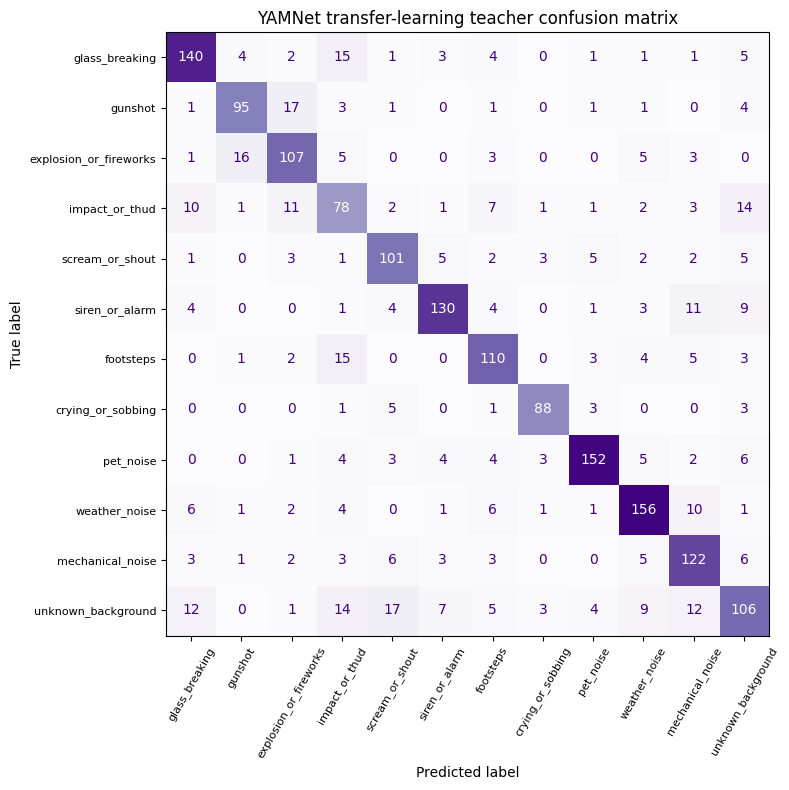

In [54]:
transfer_probs = transfer_model.predict(yamnet_test_x, verbose=0)
transfer_pred = np.argmax(transfer_probs, axis=1)

print_distribution('YAMNet transfer true label distribution:', yamnet_test_y)
print_distribution('YAMNet transfer predicted label distribution:', transfer_pred)

transfer_cm = plot_confusion(
    yamnet_test_y,
    transfer_pred,
    'YAMNet transfer-learning teacher confusion matrix',
    'yamnet_teacher_confusion_matrix.png',
    cmap='Purples',
)


## Distilled TinyML Student

This is the model we actually want to try on the ESP32.

The YAMNet transfer model above is accurate because it uses pretrained audio knowledge, but it is too heavy for direct ESP32 WROOM deployment. The student model keeps the small log-mel CNN input pipeline — no YAMNet at inference time — but it learns from two signals during training:

- the **hard label** (true class, e.g. `glass_breaking`)
- the **YAMNet teacher's soft probabilities** (e.g. `impact_or_thud: 0.72`, `explosion_or_fireworks: 0.18`, `mechanical_noise: 0.06`)

This is knowledge distillation (Hinton et al. 2015). The loss is a weighted sum:

```text
loss = alpha * CrossEntropy(hard) + (1 - alpha) * KLDivergence(soft) * T²
     = 0.25 * CE  +  0.75 * KL * 9     (T=3.0, alpha=0.25)
```

The temperature T=3.0 softens the teacher's probability distribution, giving the student more information about which classes the teacher considers similar. Uniform sample weights are used throughout — applying class weights from an imbalanced dataset to a balanced distillation split caused class collapse in earlier versions.

The student architecture (v10) adds BatchNormalization after each SeparableConv2D block:

```text
Input (171 × 64 × 1 log-mel spectrogram)
→ Normalization
→ SeparableConv2D(32)  → BatchNorm → MaxPool
→ SeparableConv2D(64)  → BatchNorm → MaxPool
→ SeparableConv2D(96)  → BatchNorm → MaxPool
→ SeparableConv2D(128) → BatchNorm → GlobalAveragePool
→ Dropout(0.25) → Dense(128) → Dense(12)
```

Estimated int8 size: ~64 KB (BatchNorm parameters are negligible at int8). This fits comfortably in ESP32 flash (4 MB) and the tensor arena stays within the 320 KB RAM budget.

**Training (v10):** Gaussian noise augmentation is applied to spectrograms during distillation. Mixup (v9) caused a regression from 66.9% to 64.0% and has been removed — blending acoustically diverse spectrograms created unrealistic examples that the distillation signal could not recover from.


In [55]:
def build_feature_matrix(ds_paths, ds_labels, name):
    features = []
    for i, path in enumerate(ds_paths):
        if i % 40 == 0:
            print(f"{name}: {i}/{len(ds_paths)}", flush=True)
        waveform = decode_audio(tf.constant(path))
        feature = waveform_to_features(waveform).numpy()
        features.append(feature)
    return np.stack(features).astype(np.float32), ds_labels.astype(np.int64)

def _student_cache_dir():
    if DRIVE_ROOT:
        d = DRIVE_ROOT / "cache" / FEATURE_CACHE_VERSION / "student"
        d.mkdir(parents=True, exist_ok=True)
        return d
    return None

def load_or_build_student(ds_paths, ds_labels, split_name):
    cache_dir = _student_cache_dir()
    fx = cache_dir / f"{split_name}_x.npy" if cache_dir else None
    fy = cache_dir / f"{split_name}_y.npy" if cache_dir else None
    if fx and fx.exists() and fy and fy.exists():
        print(f"Loading student {split_name} features from Drive cache...")
        return np.load(str(fx)), np.load(str(fy))
    print(f"Computing student {split_name} features (will cache to Drive)...")
    x, y = build_feature_matrix(ds_paths, ds_labels, split_name)
    if fx:
        np.save(str(fx), x)
        np.save(str(fy), y)
        print(f"Cached {split_name} features to Drive: {fx}")
    return x, y

student_train_x, student_train_y = load_or_build_student(train_paths, train_labels, "train")
student_val_x,   student_val_y   = load_or_build_student(val_paths,   val_labels,   "val")
student_test_x,  student_test_y  = load_or_build_student(test_paths,  test_labels,  "test")
print(student_train_x.shape, student_val_x.shape, student_test_x.shape)


Loading student train features from Drive cache...
Loading student val features from Drive cache...
Loading student test features from Drive cache...
(8534, 171, 64, 1) (1828, 171, 64, 1) (1830, 171, 64, 1)


In [56]:
def build_student_model(input_shape, num_labels):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Normalization(),
        tf.keras.layers.SeparableConv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.SeparableConv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.SeparableConv2D(96, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.SeparableConv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_labels),
    ])
    model.layers[0].adapt(student_train_x)
    return model


class DistilledStudent(tf.keras.Model):
    def __init__(self, student, temperature=3.0, alpha=0.25):
        super().__init__()
        self.student = student
        self.temperature = temperature
        self.alpha = alpha
        self.hard_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
        self.soft_loss_fn = tf.keras.losses.KLDivergence(reduction='none')
        # No sample_weight on accuracy -> honest unweighted metric
        self.accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')

    @property
    def metrics(self):
        return [self.loss_tracker, self.accuracy_metric]

    def _distill_loss(self, x, y_and_teacher, sample_weight, training):
        y_true = tf.cast(y_and_teacher[:, 0], tf.int32)
        teacher_probs = y_and_teacher[:, 1:]
        sample_weight = tf.cast(sample_weight, tf.float32)
        student_logits = self.student(x, training=training)
        hard_loss = self.hard_loss_fn(y_true, student_logits)
        teacher_soft = tf.pow(teacher_probs, 1.0 / self.temperature)
        teacher_soft = teacher_soft / tf.reduce_sum(teacher_soft, axis=1, keepdims=True)
        student_soft = tf.nn.softmax(student_logits / self.temperature, axis=1)
        soft_loss = self.soft_loss_fn(teacher_soft, student_soft) * (self.temperature ** 2)
        per_example = self.alpha * hard_loss + (1.0 - self.alpha) * soft_loss
        return (tf.reduce_sum(per_example * sample_weight) / tf.reduce_sum(sample_weight),
                y_true, student_logits)

    def train_step(self, data):
        x, y_and_teacher, sample_weight = data
        with tf.GradientTape() as tape:
            loss, y_true, logits = self._distill_loss(x, y_and_teacher, sample_weight, training=True)
        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.student.trainable_variables),
                                           self.student.trainable_variables))
        self.loss_tracker.update_state(loss)
        self.accuracy_metric.update_state(y_true, logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y_and_teacher, sample_weight = data
        loss, y_true, logits = self._distill_loss(x, y_and_teacher, sample_weight, training=False)
        self.loss_tracker.update_state(loss)
        self.accuracy_metric.update_state(y_true, logits)
        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs, training=False):
        return self.student(inputs, training=training)


def make_distill_dataset(x, y, teacher_probs, shuffle=False, add_noise=False, add_mixup=False, mixup_alpha=0.2):
    y_and_teacher = np.concatenate(
        [y.reshape(-1, 1).astype(np.float32), teacher_probs.astype(np.float32)], axis=1
    )
    weights = np.ones(len(y), dtype=np.float32)  # uniform: distillation split is already balanced
    ds = tf.data.Dataset.from_tensor_slices((x, y_and_teacher, weights))
    if shuffle:
        ds = ds.shuffle(len(x), seed=42, reshuffle_each_iteration=True)
    if add_noise:
        def _noise(xi, yt, w):
            return xi + tf.random.normal(tf.shape(xi), stddev=0.1), yt, w
        ds = ds.map(_noise, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if add_mixup:
        _alpha = float(mixup_alpha)
        def _mixup_batch(bx, byt, bw):
            n = tf.shape(bx)[0]
            # Sample lambda from Beta(alpha, alpha) via ratio of Gamma samples.
            g1 = tf.random.gamma([n], alpha=_alpha)
            g2 = tf.random.gamma([n], alpha=_alpha)
            lam = g1 / (g1 + g2 + 1e-8)
            lam = tf.maximum(lam, 1.0 - lam)          # primary example always >= 0.5 weight
            idx = tf.random.shuffle(tf.range(n))
            lam_x = tf.reshape(lam, [-1, 1, 1, 1])
            lam_y = tf.reshape(lam, [-1, 1])
            bx_mix  = lam_x * bx + (1.0 - lam_x) * tf.gather(bx, idx)
            t_mix   = lam_y * byt[:, 1:] + (1.0 - lam_y) * tf.gather(byt[:, 1:], idx)
            byt_mix = tf.concat([byt[:, :1], t_mix], axis=1)  # hard label from primary
            return bx_mix, byt_mix, bw
        ds = ds.map(_mixup_batch, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


teacher_train_probs = transfer_model.predict(yamnet_train_x, verbose=0)
teacher_val_probs   = transfer_model.predict(yamnet_val_x,   verbose=0)
teacher_test_probs  = transfer_model.predict(yamnet_test_x,  verbose=0)

distill_train_ds = make_distill_dataset(student_train_x, student_train_y, teacher_train_probs, shuffle=True, add_noise=True)
distill_val_ds   = make_distill_dataset(student_val_x,   student_val_y,   teacher_val_probs)
distill_test_ds  = make_distill_dataset(student_test_x,  student_test_y,  teacher_test_probs)

student_core    = build_student_model(INPUT_SHAPE, len(LABELS))
distilled_model = DistilledStudent(student_core, temperature=3.0, alpha=0.25)
distilled_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007))
student_core.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 171, 64, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 171, 64, 32)    │            73 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 85, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 85, 32, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 42, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_6              │ (None, 42, 16, 96)     │         6,816 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 21, 8, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_7              │ (None, 21, 8, 128)     │        13,280 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,632 (158.72 KB)

 Trainable params: 40,629 (158.71 KB)

 Non-trainable params: 3 (16.00 B)

Loaded distilled student from Drive: /content/drive/MyDrive/tinyml_models/distilled_student_checkpoint_v9.keras
Distilled student test accuracy: 0.6426229508196721
Distilled student true label distribution:
  glass_breaking               177
  gunshot                      124
  explosion_or_fireworks       140
  impact_or_thud               131
  scream_or_shout              130
  siren_or_alarm               167
  footsteps                    143
  crying_or_sobbing            101
  pet_noise                    184
  weather_noise                189
  mechanical_noise             154
  unknown_background           190
Distilled student predicted label distribution:
  glass_breaking               207
  gunshot                      138
  explosion_or_fireworks       108
  impact_or_thud               164
  scream_or_shout              138
  siren_or_alarm               200
  footsteps                    146
  crying_or_sobbing            81
  pet_noise                    188
  weather_n

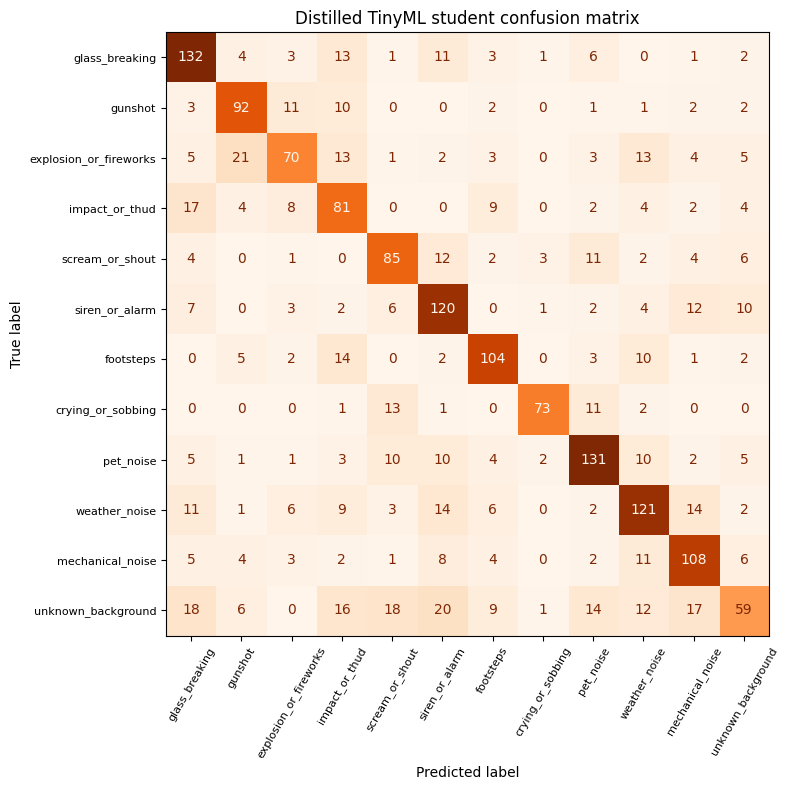

In [57]:
_student_ckpt = DRIVE_ROOT / f'distilled_student_checkpoint_{STUDENT_VERSION}.keras' if DRIVE_ROOT else None

_load_student = False
if _student_ckpt and _student_ckpt.exists():
    _probe = tf.keras.models.load_model(str(_student_ckpt))
    if _probe.output_shape[-1] != len(LABELS):
        print(f'Stale student checkpoint ({_probe.output_shape[-1]} classes). Deleting and retraining.')
        _student_ckpt.unlink()
    else:
        student_core = _probe
        distilled_history = None
        _load_student = True
        print('Loaded distilled student from Drive:', _student_ckpt)

if not _load_student:
    print('Training distilled student — single-stage distillation (v7).')
    distilled_history = distilled_model.fit(
        distill_train_ds, validation_data=distill_val_ds, epochs=120,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', mode='max', patience=18,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_accuracy', mode='max', patience=6,
                factor=0.5, min_lr=1e-5,
            ),
        ],
    )
    if _student_ckpt:
        student_core.save(str(_student_ckpt))
        print('Saved distilled student to Drive:', _student_ckpt)

student_logits   = student_core.predict(student_test_x, verbose=0)
student_probs    = tf.nn.softmax(student_logits, axis=1).numpy()
student_pred     = np.argmax(student_probs, axis=1)
student_accuracy = float(np.mean(student_pred == student_test_y))
print('Distilled student test accuracy:', student_accuracy)

print_distribution('Distilled student true label distribution:',     student_test_y)
print_distribution('Distilled student predicted label distribution:', student_pred)

distilled_cm = plot_confusion(
    student_test_y, student_pred,
    'Distilled TinyML student confusion matrix',
    'distilled_student_confusion_matrix.png',
    cmap='Oranges',
)


In [58]:
# Save distilled student checkpoint to Drive immediately after training.
try:
    import google.colab  # type: ignore
    _in_colab2 = True
except ImportError:
    _in_colab2 = False

if _in_colab2:
    from pathlib import Path
    drive_root2 = Path("/content/drive/MyDrive/tinyml_models")
    if Path("/content/drive").exists():
        drive_root2.mkdir(parents=True, exist_ok=True)
        _ckpt = drive_root2 / f"distilled_student_checkpoint_{STUDENT_VERSION}.keras"
        student_core.save(str(_ckpt))
        print("Distilled student saved to Drive:", _ckpt)
    else:
        print("Drive not mounted — skipping checkpoint.")


Distilled student saved to Drive: /content/drive/MyDrive/tinyml_models/distilled_student_checkpoint_v9.keras


## Quantize The Distilled Student

This section converts the distilled student into the actual ESP32 candidate artifact. The exported model is still a compact log-mel CNN, but its training was guided by YAMNet.


Saved artifact at '/tmp/tmpr6az64ls'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 171, 64, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  136782548565072: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  136782548562960: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  136782548563152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548561040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548562768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548556816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548558160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548556048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548562384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136782548556432: TensorSpec(shape=(), dtype=tf.resource, name=Non

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: /content/models/distilled_student_model.keras
Saved: /content/models/distilled_student_float32.tflite
Saved: /content/models/distilled_student_int8.tflite
Distilled int8 size bytes: 65808


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Distilled int8 TFLite test accuracy: 0.6398907103825137
Saved confusion matrix: /content/exported/figures/distilled_student_int8_confusion_matrix.png


array([[132,   4,   3,  13,   2,  10,   4,   1,   4,   1,   1,   2],
       [  2,  93,  11,  10,   0,   0,   2,   0,   1,   1,   2,   2],
       [  6,  22,  73,  12,   1,   2,   3,   0,   3,  12,   3,   3],
       [ 16,   4,   9,  80,   0,   0,  10,   0,   2,   5,   1,   4],
       [  4,   0,   1,   0,  83,  12,   2,   3,  14,   2,   4,   5],
       [  7,   0,   3,   2,   6, 119,   0,   1,   3,   5,  11,  10],
       [  0,   5,   2,  14,   0,   2, 105,   0,   4,   8,   1,   2],
       [  0,   0,   0,   1,  12,   1,   0,  73,  12,   2,   0,   0],
       [  5,   2,   1,   3,  10,  11,   4,   3, 130,  10,   2,   3],
       [ 11,   1,   8,  10,   3,  12,   6,   0,   2, 122,  12,   2],
       [  4,   4,   3,   2,   0,   8,   6,   0,   2,  16, 103,   6],
       [ 17,   6,   0,  18,  17,  19,   9,   1,  15,  13,  17,  58]])

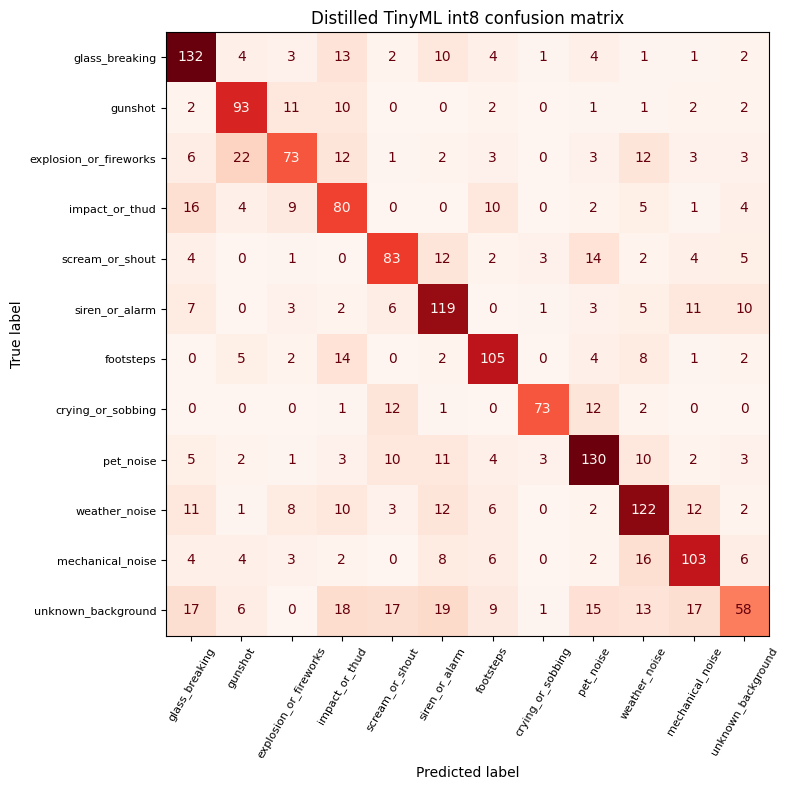

In [59]:
distilled_keras_path = MODELS_DIR / 'distilled_student_model.keras'
distilled_float_tflite_path = MODELS_DIR / 'distilled_student_float32.tflite'
distilled_int8_tflite_path = MODELS_DIR / 'distilled_student_int8.tflite'

student_core.save(distilled_keras_path)

converter = tf.lite.TFLiteConverter.from_keras_model(student_core)
distilled_float_tflite = converter.convert()
distilled_float_tflite_path.write_bytes(distilled_float_tflite)

def representative_student_dataset():
    for feature in student_train_x[:120]:
        yield [feature[np.newaxis, ...].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(student_core)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_student_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
distilled_int8_tflite = converter.convert()
distilled_int8_tflite_path.write_bytes(distilled_int8_tflite)

print('Saved:', distilled_keras_path)
print('Saved:', distilled_float_tflite_path)
print('Saved:', distilled_int8_tflite_path)
print('Distilled int8 size bytes:', distilled_int8_tflite_path.stat().st_size)

distilled_tflite_eval = evaluate_tflite_model(distilled_int8_tflite_path, test_ds)
print('Distilled int8 TFLite test accuracy:', distilled_tflite_eval['accuracy'])

plot_confusion(
    distilled_tflite_eval['y_true'],
    distilled_tflite_eval['y_pred'],
    'Distilled TinyML int8 confusion matrix',
    'distilled_student_int8_confusion_matrix.png',
    cmap='Reds',
)


In [60]:
print('Final comparison')
print(f"Scratch regular accuracy:          {regular_accuracy:.3f}")
print(f"Plain scratch int8 accuracy:       {tiny_tflite_eval['accuracy']:.3f}")
print(f"YAMNet teacher accuracy:           {transfer_accuracy:.3f}")
print(f"Distilled student accuracy:        {student_accuracy:.3f}")
print(f"Distilled student int8 accuracy:   {distilled_tflite_eval['accuracy']:.3f}")
print(f"Plain scratch int8 size bytes:     {size_tiny_tflite}")
print(f"Distilled student int8 size bytes: {distilled_int8_tflite_path.stat().st_size}")


Final comparison
Scratch regular accuracy:          0.647
Plain scratch int8 accuracy:       0.645
YAMNet teacher accuracy:           0.757
Distilled student accuracy:        0.643
Distilled student int8 accuracy:   0.640
Plain scratch int8 size bytes:     215552
Distilled student int8 size bytes: 65808


## Export Tiny Model As C Array

TFLite Micro examples often include the model as a C/C++ byte array. This export is not the full ESP32 firmware yet, but it creates the artifact shape that firmware would include later.

In [61]:
def bytes_to_c_array(data, variable_name):
    hex_values = ', '.join(f'0x{byte:02x}' for byte in data)
    return (
        f'const unsigned char {variable_name}[] = {{{hex_values}}};\n'
        f'const unsigned int {variable_name}_len = {len(data)};\n'
    )

c_path = EXPORTED_DIR / 'distilled_student_int8.cc'
c_path.write_text(bytes_to_c_array(distilled_int8_tflite_path.read_bytes(), 'distilled_student_int8'), encoding='utf-8')
print('Saved:', c_path)
print('C array size:', c_path.stat().st_size, 'bytes')


Saved: /content/exported/distilled_student_int8.cc
C array size: 394952 bytes


## Connection To The openHAB Safety System

In the existing openHAB project, the ESP8266/Tasmota nodes publish summarized sensor states such as motion, vibration, temperature, and touch acknowledgement. The ESP32 audio node follows the same idea: it does not stream raw audio into openHAB.

Once the TinyML model is deployed, the audio node will publish summarized inference data:

```json
{
  "label": "glass_breaking",
  "confidence": 0.87,
  "rms": 421,
  "inference_ms": 18,
  "model": "distilled_student_int8"
}
```

Planned MQTT topic:

```text
tele/safety_audio_1/CLASSIFICATION
```

Raw samples are still inspectable during development through the notebook, serial monitor, or temporary debug MQTT topics. They are not part of the normal openHAB data path.

## Interpretation Template

Use the results above to fill this in for the report/presentation:

- The scratch TensorFlow model shows what a compact CNN learns from the multi-dataset training set (ESC-50 + UrbanSound8K + FSD50K + Donate-a-cry) using only log-mel features and no pretrained knowledge.
- The plain quantized TFLite model shows the basic TinyML tradeoff: smaller deployment artifact, possible accuracy loss from int8 quantization.
- The YAMNet transfer-learning teacher shows how much pretrained audio knowledge (trained on AudioSet) improves accuracy on the same task.
- The distilled student is the main ESP32 candidate: it is small like the TinyML model, but its training was guided by the stronger YAMNet teacher.
- The deployed ESP32 design keeps ML and policy separate: predict a real sound class first, then map that class to a risk category in firmware/openHAB.
- openHAB should receive summarized classification data, not continuous raw audio.

A good conclusion sentence could be:

```text
The final TinyML model is not just a smaller copy of the regular model; it uses a
stronger teacher during training and then runs locally as a compact int8 student
on the edge node, publishing only label, confidence, and inference time to openHAB.
```
